
# Analyse de la typhoïde 

Ce notebook réalise une **analyse descriptive et statistique complète** des données liées à la typhoïde,
conformément aux exigences académiques.
Chaque cellule est **commentée** pour expliquer clairement son objectif.

## Importation des bibliothèques/Librairies

In [1]:

# pandas : manipulation des données
# numpy : calculs numériques
# matplotlib : visualisation


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Chargement des données


In [2]:
# Le fichier CSV contient les données brutes de l'étude
df = pd.read_csv("typhoide_health_data.csv")

In [3]:
df.head()

,Age,Sexe,Region,Temperature,Duree_fievre,Test_typhoide,Source_eau,Acces_assainissement,Antibiotherapie
0,15,M,Est,37.0,3,Negatif,Riviere,Oui,Oui
1,55,M,Nord,36.1,4,Negatif,Potable,Oui,Oui
2,70,F,Sud,38.2,5,Negatif,Potable,Oui,Oui
3,55,F,Est,36.4,13,Positif,Potable,Non,Oui
4,46,F,Est,40.3,12,Positif,Potable,Non,Oui


## **Exercice 1 : Exploration initiale et profilage des données**

### Comprendre la structure

Taille du jeu de donnée

In [4]:
df.shape

(300, 9)

Le jeu de donnée présente: 
* **300 lignes**
* **9 colonnes**

 Type de variable de chaque colonne.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   300 non-null    int64  
 1   Sexe                  300 non-null    object 
 2   Region                300 non-null    object 
 3   Temperature           300 non-null    float64
 4   Duree_fievre          300 non-null    int64  
 5   Test_typhoide         300 non-null    object 
 6   Source_eau            300 non-null    object 
 7   Acces_assainissement  300 non-null    object 
 8   Antibiotherapie       300 non-null    object 
dtypes: float64(1), int64(2), object(6)
memory usage: 21.2+ KB


sur les 9 colonnes nous avons : 
* **Entier(int64)** : Age, Duree_fievre.
* **Réelle(float64)** : Temperature.
* **Chaine de caractère(object)** : Sexe, region, Test_typhoide, Source_eau, Acces_assainissement, Antibiotherapie.

### Valeurs manquantes et doublons

In [6]:
df.isnull().sum()

Age                     0
Sexe                    0
Region                  0
Temperature             0
Duree_fievre            0
Test_typhoide           0
Source_eau              0
Acces_assainissement    0
Antibiotherapie         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

On peu remarquer que le jeu de donnée est déja bien avec **aucune valeur manquante et aucun doublon**.

### Statistique descriptive pour l'**age** et la **durée de la fièvre**.

In [8]:
# Résumé statistique des variables numériques
df.describe()

,Age,Temperature,Duree_fievre
count,300.000000,300.000000,300.000000
mean,39.993333,38.543667,7.360000
std,22.276462,1.707311,3.994612
min,1.000000,35.500000,1.000000
25%,20.000000,37.100000,4.000000
50%,39.500000,38.600000,7.000000
75%,58.250000,40.000000,11.000000
max,80.000000,41.500000,14.000000


In [9]:
df[["Age", "Duree_fievre"]].describe()

,Age,Duree_fievre
count,300.000000,300.000000
mean,39.993333,7.360000
std,22.276462,3.994612
min,1.000000,1.000000
25%,20.000000,4.000000
50%,39.500000,7.000000
75%,58.250000,11.000000
max,80.000000,14.000000


L'on remarque que les statistiques consolidées sont :

- **Moyenne (mean)** : elle est de **39.99** pour l'âge, **38.54**°C pour la température et **7.36** jours pour la durée de la fièvre. On note que les patients positifs présentent des moyennes plus élevées (38.92°C / 8.16 jours) que les patients négatifs (37.94°C / 6.08 jours).

- **Écart-type (std)** : il est de **22.28** pour l'âge, **1.71** pour la température et **3.99** pour la durée de la fièvre. La dispersion de la température est plus faible chez les positifs (1.58) que chez les négatifs (1.73), indiquant des symptômes plus constants chez les malades.

- **Minimum (min)** : il est de **1** pour l'âge, **35.59**°C pour la température et **1** jour pour la durée de la fièvre.

- **Maximum (max)** : il est de **80** pour l'âge, **41.59**°C pour la température et **14** jours pour la durée de la fièvre.

- **25ème percentile (25%)** : il est de **20** pour l'âge, **37.10**°C pour la température et **4** jours pour la durée de la fièvre.

- **Médiane (50%)** : elle est de **39.5** pour l'âge, **38.60**°C pour la température et **7** jours pour la durée de la fièvre.

- **75ème percentile (75%)** : il est de **58.25** pour l'âge, **40.00**°C pour la température et **11** jours pour la durée de la fièvre.


En résumé, l'analyse des données montre que la fièvre typhoïde dans cet échantillon se manifeste par une signature clinique distincte : les patients testés positifs ont une température plus élevée (proche de 39°C) et une durée de symptômes prolongée (plus de 8 jours) par rapport aux cas négatifs. L'âge ne semble pas être un facteur limitant, la maladie touchant toutes les tranches de la population (de 1 à 80 ans). Enfin, la faible variabilité de la température chez les patients positifs suggère que la forte fièvre persistante est le prédicteur le plus fiable de la maladie, tandis que les fièvres plus courtes et variées chez les patients négatifs pourraient indiquer d'autres pathologies.

### Exploration de la distribution température corporelle

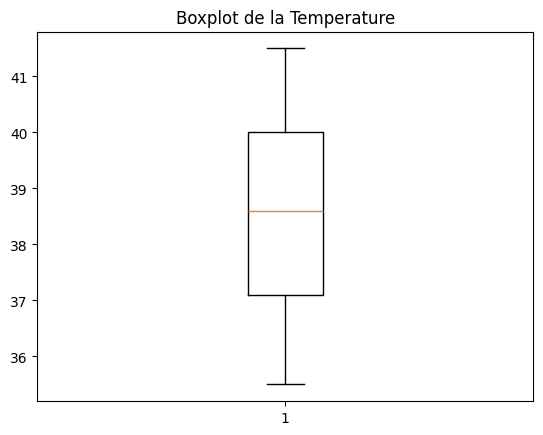

In [10]:
plt.boxplot(df["Temperature"])
plt.title("Boxplot de la Temperature")
plt.show()

Après analyse de la **boîte à moustaches** de la colonne température, l'on remarque que le jeu de donnée ne présente aucune valeur abérrante(valeur extrêmes par rapport à la majorité). L’absence de valeurs aberrantes sur le boxplot indique que la distribution des températures est homogène et cohérente.

### Les valeurs uniques pour le **sexe**, le résultat du **test typhoïde**, la **source d’eau**


In [11]:
df["Sexe"].unique()

array(['M', 'F'], dtype=object)

In [12]:
df["Test_typhoide"].unique()

array(['Negatif', 'Positif'], dtype=object)

In [13]:
df["Source_eau"].unique()

array(['Riviere', 'Potable', 'Puits'], dtype=object)

Les valeurs uniques retrouver sont : 
* **Sexe** : **M** et **F**, pour Masculin et feminin.
* **Test_typhoide** : **Negatif** et **Positif**.
* **Source_eau** : **Riviere**, **Potable** et **Puits**.

## **Exercice 2 : Analyse descriptive et épidémiologique**

### Température moyenne entre les patients : testés positifs et testés négatifs.


In [14]:
df.groupby('Test_typhoide')['Temperature'].mean()

Test_typhoide
Negatif    37.936522
Positif    38.921081
Name: Temperature, dtype: float64

Le jeu de donnée présente en moyenne **37.93°** pour les patient négatif et **38.92°** pour les patients positif à la typhoïde.

### Taux de positivité à la typhoïde par région

In [15]:
# unstack() transforme les index en colonnes
# normalize=True permet d'avoir les pourcentages
# multiply(100) pour convertir en pourcentage

df.groupby('Region')['Test_typhoide'].value_counts(normalize=True).unstack()['Positif'].multiply(100).round(2)

Region
Est      66.20
Nord     56.94
Ouest    65.26
Sud      56.45
Name: Positif, dtype: float64

Dans chaque région on a : 
* **Est**  : 66.20% de personne positive à la thyphoïde.
* **Nord** : 56.94% de personne positive à la thyphoïde.
* **Ouest**: 65.26% de personne positive à la thyphoïde.
* **Sud**  : 56.45% de personne positive à la thyphoïde.

### Évaluons si les personnes sans accès à l’assainissement sont plus souvent testées positives

In [16]:
df.groupby('Acces_assainissement')['Test_typhoide'].value_counts(normalize=True).unstack()['Positif'].multiply(100).round(2)

Acces_assainissement
Non    64.38
Oui    59.09
Name: Positif, dtype: float64

Donc les personnes qui sans accès à l'assainissement sont plus testé positif. 

### Comparons la durée moyenne de la fièvre entre les patients positifs et négatifs.

In [17]:
df.groupby('Test_typhoide')['Duree_fievre'].mean()

Test_typhoide
Negatif    6.078261
Positif    8.156757
Name: Duree_fievre, dtype: float64

En moyenne en fonction des patients, la fière dure : 
* **Negatif**: **6.07** jours
* **Positif**: **8.15** jours

### Analysons l’association entre la source d’eau et le résultat du test

In [18]:
df.groupby('Source_eau')['Test_typhoide'].value_counts(normalize=True).unstack()['Positif'].multiply(100).round(2)

Source_eau
Potable    64.95
Puits      59.60
Riviere    60.58
Name: Positif, dtype: float64

Les taux de positivité à la typhoïde selon la source d'eau sont les suivants :
* **Potable** : 64.95% de personnes positives.
* **Puits** : 59.60% de personnes positives.
* **Rivière** : 60.58% de personnes positives.

On remarque que les personnes utilisant l'eau potable ont le taux de positivité le plus élevé, suivi de la rivière, tandis que le puits présente le taux le plus faible.

## **Exercice 3 : Analyse de la qualité des données**

### Identifions les valeurs de température physiologiquement impossibles

In [19]:
print(f"Température minimale : {df['Temperature'].min()} °C")
print(f"Température maximale : {df['Temperature'].max()} °C")

Température minimale : 35.5 °C
Température maximale : 41.5 °C


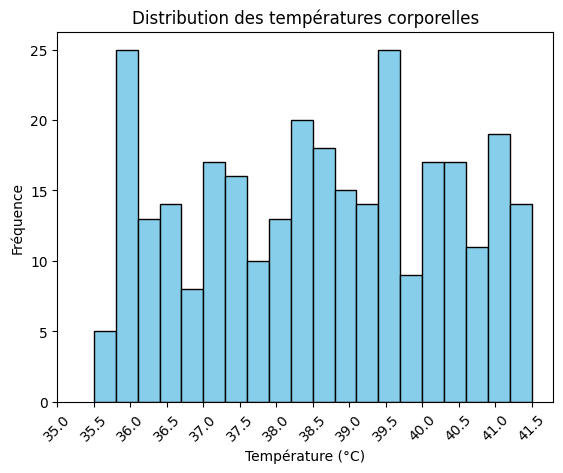

In [20]:
plt.hist(df["Temperature"], bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution des températures corporelles")
plt.xticks(np.arange(35, 42, 0.5))
plt.xticks(rotation=45)
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.show()

Valeurs impossibles ou non plausibles sont : **en dessous de 25 °C** et **au-dessus de 45 °C**. Mais nous remarquons que notre jeu de donnée reste compris entre l'intervalle [35.5, 41.5] donc des valeurs sûr.
Pourquoi elles posent problème : 
- Elles faussent l’analyse épidémiologique.
- Elles masquent les tendances réelles : la corrélation entre fièvre et test positif.
- Elles compromettent la qualité des conclusions : risque de faux résultats statistiques.

### Comptons les valeurs manquantes dans la variable Durée_fièvre et discutons : suppression, imputation ou conservation.

In [21]:
print(f"La colonne Duree_fievre contient : {df['Duree_fievre'].isnull().sum()} valeurs manquantes.")

La colonne Duree_fievre contient : 0 valeurs manquantes.


si : 
* Peu de valeurs manquantes : **suppression**.
* Beaucoup de valeurs manquantes : **imputation**.
* Analyse exploratoire : **conservation** pour montrer la réalité des données.

Donc dans notre cas rien à faire.

### Vérifions les incohérences dans les colonnes **Sexe** et **Test_typhoide** 

In [22]:
df["Sexe"].unique()

array(['M', 'F'], dtype=object)

In [23]:
df["Test_typhoide"].unique()

array(['Negatif', 'Positif'], dtype=object)

**Conclusion** : Aucune incohérence dans les colonnes **Sexe(M et F)** et **Test_typhoide(Negatif et Positif)**.

### Règles de validation pour garantir la qualité future des données

#### 1. Valeurs numériques
- **Température corporelle** : doit être comprise entre 25 °C et 45 °C.
- **Durée de fièvre** : doit être comprise entre 0 et 60 jours.
- **Format** : uniquement des nombres réels, arrondis à 1 ou 2 décimales.

#### 2. Variables catégorielles
- **Test_typhoide** : valeurs autorisées = `Positif` ou `Négatif`.
- **Source_eau** : valeurs autorisées = `Puits`, `Robinet`, `Rivière`, `Forage`.
- **Uniformisation** : éviter les doublons dus aux majuscules/minuscules ou fautes de frappe.

#### 3. Valeurs manquantes
- **Suppression** si < 5% des données.
- **Imputation** si > 5% (moyenne, médiane ou méthode avancée).
- **Conservation** uniquement pour une analyse exploratoire.

#### 4. Cohérence inter-variables
- Si `Test_typhoide = Positif` → température généralement ≥ 38 °C.
- Si `Durée_fièvre = 0` → le test ne peut pas être `Positif`.